Erfolgreich geladen: Epoche 50000


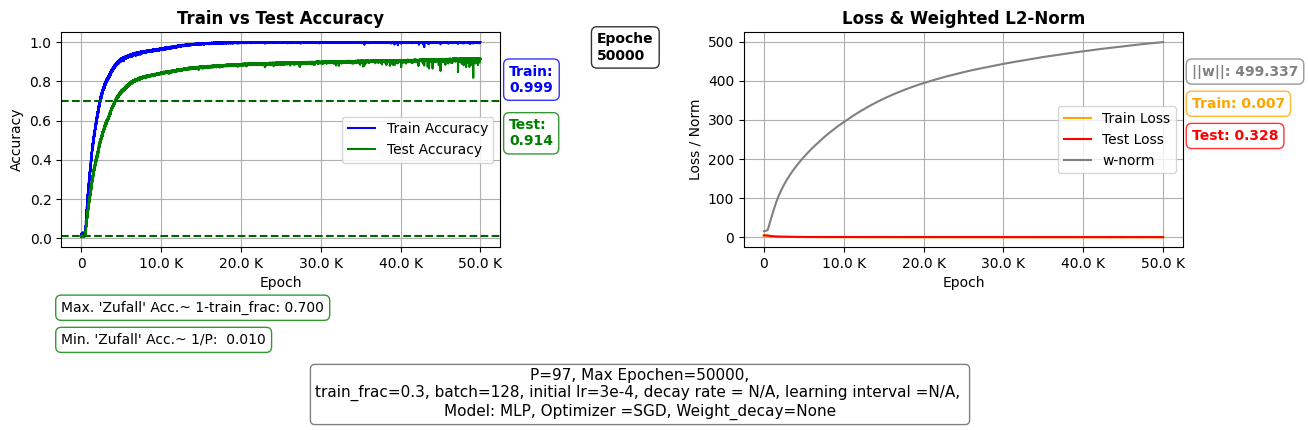

In [237]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter



#RUN_DIR = f"./runs/grok_P97_20260120_231821" problem
#RUN_DIR = f"./runs/grok_P97_20260120_224008"problem
#RUN_DIR = f"./runs/grok_P97_20260121_134318"problem

#RUN_DIR = f"./runs/grok_P97_20260121_150755"
#RUN_DIR = f"./runs/grok_P97_20260121_164226" #30%

#RUN_DIR = f"./runs/grok_P97_20260121_225910" #10%
#RUN_DIR = f"./runs/grok_P97_20260122_225634"

#RUN_DIR = f"./runs/grok_P29_20260123_093248"

#RUN_DIR = f"./runs/P29_2"
#RUN_DIR = f"./runs/P29_3"
#RUN_DIR = f"./runs/P29_4"
#RUN_DIR = f"./runs/P29_5"
#RUN_DIR = f"./runs/P29_6"

#RUN_DIR = f"./runs/grok_P29_20260123_233645" #Anomaly
#RUN_DIR = f"./runs/grok_P29_20260123_191510" #Anomaly

#RUN_DIR = f"./runs/grok_P29_20260125_024425" #ja
#RUN_DIR = f"./runs/grok_P29_20260126_011252"
#RUN_DIR = f"./runs/grok_P29_20260126_013239"
#RUN_DIR = f"./runs/grok_P29_20260126_022748" #nein?
#RUN_DIR = f"./runs/grok_P29_20260126_105913" #nein
#RUN_DIR = f"./runs/grok_P29_20260126_132005" #tiny transformer
#RUN_DIR = f"./runs/grok_P29_20260126_140509" #train_frac=0.2, WD 1:15000 dann 1.2-1.5: 150000 very chaotic
#RUN_DIR = f"./runs/grok_P29_20260126_184727" #train_frac=0.2, WD 1.5: first 15000
#RUN_DIR = f"./runs/grok_P29_20260126_200539" #train_frac=0.2, WD 1.5: first 15000 identical as the previous one!
                                              #but not really...
#RUN_DIR = f"./runs/grok_P29_20260126_192705"  #train_frac 0.5, Batch Size 32, LR 0.001, Transformer, WD 0.1


#RUN_DIR = f"./runs/grok_P29_20260126_215918"  #Hybbride: Tiny_Transformer_MLP: 
                                              #P=29, Batsch_Size 32, WD 06, LR 0.001, train_frac 0.35. 
                                              #Convergence very slow maybe bcs Batsch bigger as 
                                              #a previous situation with train_frac 0.35. Dann ab 15000 bis 
                                              # 35000 EPochen mit WD= 0.8. train_acc ist leider eine stabile 
                                              # aber nicht die optimalste Lösung gefunden

                                              
#RUN_DIR = f"./runs/grok_P29_20260127_101457"  #Hybbride: Tiny_Transformer_MLP: 
                                              #P=29, Batsch_Size 32, WD 09, LR 0.001, train_frac 0.35. 
                                              #Convergence reach after 20000 only 94.8% test accuracy.  
#RUN_DIR = f"./runs/grok_P29_20260127_112732"   #Hybbride: Tiny_Transformer_MLP: 
                                              #P=29, Batsch_Size 32, WD 09, LR 0.0005, train_frac 0.35. 
                                              #Convergence reach after 20000 only 94.8% test accuracy. 
                                              # stagniert um 82%. WG ist angeblich zu hoch um "bewegungsfreiheit"
                                              # zu schaffen: Um die letzten 7 % Genauigkeit zu erreichen, 
                                              # muss das Modell seine internen Repräsentationen (die Kreise)
                                              # extrem präzise "feinjustieren". Das erfordert oft eine 
                                              # minimale Vergrößerung bestimmter Gewichte. 
                                              # Ein WD von 0.9 wirkt wie eine zu starke mechanische Bremse.
                                              # Er bestraft diese kleine Vergrößerung der Gewichte so sehr, 
                                              # dass das Modell lieber bei 93 % Fehlern bleibt, 
                                              # als die "Energiekosten" für die perfekte Lösung zu zahlen.   
                                              # Auch das Batch ist zu gross: Eine BATCH_SIZE = 64 bedeutet, 
                                              # dass wir nur ca. 4–5 Updates pro Epoche haben.
                                              # Das Training ist dadurch "zu glatt".  
                                              # Auch ein Konstant/Fehlendes LR Decay hat eine Wirkung:
                                              # Eine konstante LR von 0.001 ist super für den ersten Sprung. 
                                              # Aber für die letzten Prozentpunkte ist sie oft zu grob. 
                                              # 
                                              # Die Lösung kann so sein:
                                              # Batch Size reduzieren: Geh auf 16 herunter. 
                                              # Das erhöht das Rauschen.
                                              # Weight Decay leicht senken: Probiere 0.6 statt 0.9, 
                                              # um dem Modell mehr "Bewegungsfreiheit" 
                                              # für die Feinjustierung zu geben.
                                              # LR-Scheduler einbauen: Nutze einen Scheduler, 
                                              # der die LR nach Epoche 5.000 langsam halbiert.   
                                              # 
                                              # 
                                                                  
#RUN_DIR = f"./runs/grok_P29_20260127_143927"  #Ohne Scheduler!
#RUN_DIR = f"./runs/grok_P29_20260127_150935" ##Mit Scheduler!!!!

#RUN_DIR = f"./runs/grok_P97_20260128_003600" #p=97! ohne scheduler train_frac= 0.1 seeeeeeehr langsam train_frac zu klein...n
#RUN_DIR = f"./runs/grok_P97_20260128_102802" ##existiert nicht   
                                             #p=97! train_frac =0.35, aber convergenz sehr schnell train_frac zu gross? 
                                             # vorher, mit train_frac= 0.40 und 128 layers, war zu chaoetisch und 
                                             # sowohl training wie testing accuracy sind gleichmessig gestiegen. ABer 
                                             # hier ist ziemlich interessant: es gab "etwas" grokking sehr...
                                             # sehr sehr früh, vielleicht eben weil der datensatz zu gross und das modell
                                             # stark ist? hier habe ich keine scheduler benutz aber vielleicht wäre es
                                             # sinnvoller auszuprobieren um das Chaoes zu vermeiden. 
                                             # leider keine checkpoints.
#RUN_DIR = f"./runs/grok_P97_20260128_104502" # now mit checpoints und scheduler, genau mit dem selber parameter als
                                             # oben für P=97   train_frac =0.35 convergenz sehr schnell 
                                             # weil train_frac zu gross?          
                                             # warum ist hier sehr langsam? als train_frac =0.1? ich habe der scheduler
                                             #  abe 500 angeschaltet, hoffentlich wird der chaos weniger?
                                             # In der Tat unmittelbar nach 500 Epochen ist die L2-norm smoother geworden 
                                             # und die train und test_acc sehr stabil um 1! also mit einer halbierte LR
                                             # von 0.0005 ist besser für die Stabilität. Aber warum so schnell gelernt? 
                                             # schon um 100 Epochen für beide, train und test_acc           
#RUN_DIR = f"./runs/grok_P97_20260128_110013" #now mit checkpoints jeder 500 und ohne scheduler, 
                                             # mit dem selber parameter als
                                             # oben für P=97  ABER train_frac =0.70 convergenz sehr schnell 
                                             # Obviously!!   ABER Stagniert für BEIDE train und Test acc um 50%! 

#RUN_DIR = f"./runs/grok_P97_20260128_111443" #now mit checkpoints jeder 100 und MIT scheduler jede 100
                                             # mit dem selber parameter als
                                             # oben für P=97  ABER train_frac =0.70 convergenz sehr schnell 
                                             # Obviously!!  
#RUN_DIR = f"./runs/grok_P97_20260128_112315" # now mit checpoints ohne scheduler, genau mit dem selber parameter als
                                             # oben für P=97   train_frac =0.25 convergenz sehr schnell 
                                             # convergence schon ab 400 für train_acc und dann auch relativ früh danach
                                             # für test_acc. Ab 200 brauche ich einen scheduler?
#RUN_DIR = f"./runs/grok_P97_20260128_120945" #                  train_frac= 0.18 decay 0.9    convergenz schnell aber 
                                              # die konnte besser sein wenn ich zB scheduler benutze ab epoche 500
#RUN_DIR = f"./runs/grok_P97_20260128_122429"   # wie oben aber mit scheduler. Sehr gut  hier decay 0.8 war genug
#RUN_DIR = f"./runs/grok_P97_20260128_131123"  # wie oben aber mit kleiner batch 16, und LR=0.0005 so sehr langsam


#Probes:
#RUN_DIR = f"./runs/grok_P97_20260119_011530"
RUN_DIR = f"./runs/grok_P97_20260121_164226"
#RUN_DIR = f"./runs/grok_P97_20260129_121958" #P=97, decay_weight =0, mlp
#RUN_DIR = f"./runs/grok_P97_20260129_133330"









CSV_PATH = os.path.join(RUN_DIR, "history.csv")


# SETTINGS AUS .TXT DATEI LESEN 
SETTINGS_PATH = os.path.join(os.path.dirname(CSV_PATH), "training_settings.txt")

def load_training_settings(path):
    # bauen wir ein Dictionary mit keys und values gegeben im .txt file
    settings = {}
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()

                # Überspringe leere Zeilen oder Zeilen, die Trenner enthalten (z.B. ===)
                if not line or line.startswith("="):
                    continue

                if ":" in line:
                    # Teilt die Zeile beim ersten Doppelpunkt
                    key, value = line.split(":", 1)
                    settings[key.strip()] = value.strip()
    return settings

# Daten laden
loaded_training_settings = load_training_settings(SETTINGS_PATH)

# Relevante Werte extrahieren (Namen exakt wie in training_settings.txt)
P = int(loaded_training_settings.get("P", "N/A"))
LR = loaded_training_settings.get("LR", "N/A")
LEARNING_INTERVAL = loaded_training_settings.get("LEARNING_INTERVAL", "N/A") #Für die Scheduler
DECAY_RATE = loaded_training_settings.get("DECAY_RATE", "N/A")  #Für die Scheduler
BATCH_SIZE = loaded_training_settings.get("BATCH_SIZE", "N/A")
MODEL_TYPE = loaded_training_settings.get("MODEL_TYPE", "N/A") 
OPTIMIZER = loaded_training_settings.get("Optimizer Name", "N/A")
WEIGHT_DECAY = loaded_training_settings.get("WEIGHT_DECAY", "N/A")
EPOCHS = loaded_training_settings.get("TOTAL_TARGET_EPOCHS", "N/A")
train_frac = loaded_training_settings.get("train_frac", "N/A")

random_guess = 1/P
random_guess_test =1-float(train_frac)





# Manuell Spaltennamen setzen
cols = ["epoch", "train_acc", "test_acc", "train_loss", "test_loss", "w_norm"]
#cols = ["epoch", "train_acc", "test_acc", "train_loss", "test_loss"]

# 2. CSV laden mit Fehlerprüfung
try:
    # usecols sorgt dafür, dass nur genau die 6 Spalten geladen werden, die wie brauchen
    history_df = pd.read_csv(CSV_PATH, names=cols, header=0, usecols=range(len(cols)))
    # oder das benutzen:
    #history_df = pd.read_csv(CSV_PATH, names=cols, header=0)  # header=0 überspringt den kaputten Header
    
    # 3. Automatische Extraktion der letzten Zeile
    # .iloc[-1] greift immer auf den aktuellsten Stand am Ende der Datei zu
    last_row = history_df.iloc[-1] 
    
    last_epoch      = int(last_row["epoch"])
    last_train_acc  = last_row["train_acc"]
    last_test_acc   = last_row["test_acc"]
    last_train_loss = last_row["train_loss"]
    last_test_loss  = last_row["test_loss"]
    last_w_norm     = last_row["w_norm"]

    print(f"Erfolgreich geladen: Epoche {last_epoch}")

except Exception as e:
    print(f"Fehler beim Laden der CSV: {e}")

#N_LAST = 3000
#history_df = history_df.tail(N_LAST).reset_index(drop=True)
#history_df = history_df.head(N_LAST).reset_index(drop=True)


# -----------------------
# Zwei Plots nebeneinander
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(15,5))

def kfmt(x, pos):
    # 1000 -> 1K, 150000 -> 150K
    if x >= 1000:
        return f"{round(x/1000,1)} K"
    return f"{int(x)}"

# -----------------------
# Plot 1: Accuracy
# -----------------------
axes[0].plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy", color="blue")
axes[0].plot(history_df["epoch"], history_df["test_acc"], label="Test Accuracy", color="green")
# Zieht eine horizontale Linie bei dem Wert von random_guess
axes[0].axhline(y=random_guess, #label="Random guess", 
                color="darkgreen", linestyle="--")
axes[0].axhline(y=random_guess_test, #label="Random guess", 
                color="darkgreen", linestyle="--")

axes[0].xaxis.set_major_formatter(FuncFormatter(kfmt))

# Jetzt ist last_epoch bekannt und kann hier genutzt werden:
axes[0].set_title("Train vs Test Accuracy", color="black", weight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True)
axes[0].legend()

# Boxen für Plot 1
axes[0].annotate(f"Epoche\n{last_epoch}", xy=(1.22, 1.0), xycoords='axes fraction',
                 va='top', ha='left', color="black", weight="bold",
                 bbox=dict(fc="none", ec="black", boxstyle="round,pad=0.4", alpha=0.8))

axes[0].annotate(f"Train:\n{last_train_acc:.3f}", xy=(1.02, 0.85), xycoords='axes fraction',
                 va='top', ha='left', color="blue", weight="bold",
                 bbox=dict(fc="none", ec="blue", boxstyle="round,pad=0.4", alpha=0.8))

axes[0].annotate(f"Test:\n{last_test_acc:.3f}", xy=(1.02, 0.60), xycoords='axes fraction',
                 va='top', ha='left', color="green", weight="bold",
                 bbox=dict(fc="none", ec="green", boxstyle="round,pad=0.4", alpha=0.8))

axes[0].annotate(f"Min. 'Zufall' Acc.~ 1/P:  {random_guess:.3f}", xy=(0, -0.40), xycoords='axes fraction',
                 va='top', ha='left', color="black", #weight="light",
                 bbox=dict(fc="none", ec="green", boxstyle="round,pad=0.4", alpha=0.8))

axes[0].annotate(f"Max. 'Zufall' Acc.~ 1-train_frac: {random_guess_test:.3f}", xy=(0, -0.25), xycoords='axes fraction',
                 va='top', ha='left', color="black", #weight="light",
                 bbox=dict(fc="none", ec="green", boxstyle="round,pad=0.4", alpha=0.8))



# -----------------------
# Plot 2: Loss
# -----------------------
axes[1].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss", color="orange")
axes[1].plot(history_df["epoch"], history_df["test_loss"], label="Test Loss", color="red")
axes[1].plot(history_df["epoch"], history_df["w_norm"], label="w-norm", color="grey")
axes[1].xaxis.set_major_formatter(FuncFormatter(kfmt))

# Auch hier ist last_epoch nun bekannt:
axes[1].set_title("Loss & Weighted L2-Norm", color="black", weight="bold")
#axes[1].set_title("Loss", color="black", weight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss / Norm")
#axes[1].set_ylabel("Loss")
axes[1].grid(True)
axes[1].legend()

# Boxen für Plot 2

#axes[1].annotate(f"Epoch:\n{last_epoch:.3f}", xy=(1.02, 1.0), xycoords='axes fraction',
#                 va='top', ha='left', color="black", weight="bold",
#                 bbox=dict(fc="none", ec="black", boxstyle="round,pad=0.4", alpha=0.8))

axes[1].annotate(f"||w||: {last_w_norm:.3f}", xy=(1.02, 0.85), xycoords='axes fraction',
                 va='top', ha='left', color="grey", weight="bold",
                bbox=dict(fc="none", ec="grey", boxstyle="round,pad=0.4", alpha=0.8))

axes[1].annotate(f"Train: {last_train_loss:.3f}", xy=(1.02, 0.70), xycoords='axes fraction',
                 va='top', ha='left', color="orange", weight="bold", # Textfarbe angepasst
    bbox=dict(fc="none", ec="orange", boxstyle="round,pad=0.4", alpha=0.8) # Rahmenfarbe angepasst
    )

axes[1].annotate(f"Test: {last_test_loss:.3f}", xy=(1.02, 0.55), xycoords='axes fraction',
                 va='top', ha='left', color="red", weight="bold",
                 bbox=dict(fc="none", ec="red", boxstyle="round,pad=0.4", alpha=0.8))


                

# 3. ZENTRIERTE INFO UNTEN & LAYOUT
config_text = f"P={P}, Max Epochen={EPOCHS},\ntrain_frac={train_frac}, batch={BATCH_SIZE}, initial lr={LR}, decay rate = {DECAY_RATE}, learning interval ={LEARNING_INTERVAL}, \nModel: {MODEL_TYPE}, Optimizer ={OPTIMIZER}, Weight_decay={WEIGHT_DECAY}"
fig.text(0.43, 0.1, config_text, ha='center', va='bottom', color="black", fontsize=11,
         bbox=dict(boxstyle='round', fc='none', alpha=0.5))

#plt.tight_layout(rect=[0, 0.05, 0.88, 1])
# 1. Alles fertig plotten und Layout anpassen
plt.tight_layout(rect=[0, 0.08, 0.88, 0.95])

#Speichern
SAVE_PATH = os.path.join(os.path.dirname(CSV_PATH), f"Grokking_Experiment_P_{P}_Plot.pdf")
plt.savefig(SAVE_PATH, format='pdf', bbox_inches='tight')

#Anzeigen
plt.show()

In [242]:
import os
from pypdf import PdfWriter

#Der Pfad (ohne den Punkt am Ende)
PLOTS_PDF_DIR = "./Grokking_docs/Experimente_Plots_PDF"

merger = PdfWriter()

# Erfassen wir alle Dateien im PLOTS_PDF_DIR, die auf .pdf enden
for filename in sorted(os.listdir(PLOTS_PDF_DIR)):
    #if filename.endswith(".pdf") and filename.startswith("Grokking_Experiment_P_97_"): # for P=97,29
    #if filename.endswith(".pdf") and filename.startswith(("Prae", "Snip")):
    if filename.endswith(".pdf"):
        # Wichtig: Pfad und Dateiname kombinieren!
        filepath = os.path.join(PLOTS_PDF_DIR, filename)
        merger.append(filepath)

merger.write("./Grokking_docs/Praesentation_mit_Snippets_und_Plots_Melanie_DSBS_WIFI.pdf")
#merger.write("./Grokking_docs/Praesentation_mit_Snippets_Melanie_DSBS_WIFI.pdf")
#merger.write("./Grokking_docs/Anfang_Selected_Plots_Grokking_P_97.pdf") #for P=97 am Anfang der Presäntation
#merger.write("./Grokking_docs/Ende_Selected_Plots_Grokking_P_97.pdf") #for P=97 am Ende der Presäntation
#merger.write("./Grokking_docs/MLP_Selected_Plots_Grokking_P_29.pdf") #for P=29 mit mlp ohne embbeding, skaliert
#merger.write("./Grokking_docs/Transformer_Selected_Plots_Grokking_P_29.pdf") #for P=29 mit mlp und attention ohne embbeding, skaliert
merger.close()

In [146]:
%pip install ipympl

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
%pip show ipympl

Name: ipympl
Version: 0.10.0
Summary: Matplotlib Jupyter Extension
Home-page: http://matplotlib.org/ipympl
Author: 
Author-email: Matplotlib Development Team <matplotlib-users@python.org>
License: Copyright (c) 2016, Matplotlib Contributors
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

1. Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

2. Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

3. Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS

In [6]:
# %matplotlib qt5 #(oder %matplotlib qt) – Dies ist der Standard für separate Fenster. 
                    # Erfordert PyQt5 oder PySide2. Matplotlib Qt Backend
# %matplotlib tk – Nutzt Tkinter (ist oft standardmäßig bei Python dabei). 
                #Es ist etwas altbackener, braucht aber meist keine extra Installation.
                #  Matplotlib Tkinter Backend

In [7]:
%matplotlib tk

In [21]:
# %matplotlib widget
# import matplotlib.pyplot as plt

# # Test-Plot
# plt.figure()
# plt.plot([1, 2, 3], [4, 5, 6])
# plt.title("Wenn du das siehst, klappt ipympl!")
# plt.show()

In [22]:
# %matplotlib tk 
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# from matplotlib.ticker import FuncFormatter
# import pandas as pd

# # 1. Figure erstellen
# # Das Fenster sollte jetzt aufpoppen (vielleicht hinter VS Code!)
# fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# # Initialisiere leere Linien-Objekte für Plot 1
# line_train_acc, = axes[0].plot([], [], label="Train Accuracy", color="blue")
# line_test_acc, = axes[0].plot([], [], label="Test Accuracy", color="green")
# axes[0].axhline(y=random_guess, color="darkgreen", linestyle="--")
# axes[0].axhline(y=random_guess_test, color="darkgreen", linestyle="--")

# # Initialisiere leere Linien-Objekte für Plot 2
# line_train_loss, = axes[1].plot([], [], label="Train Loss", color="orange")
# line_test_loss, = axes[1].plot([], [], label="Test Loss", color="red")
# line_wnorm, = axes[1].plot([], [], label="w-norm", color="grey")

# # Achsen-Konfiguration (Labels, Grid etc. einmalig setzen)
# for ax in axes:
#     ax.grid(True)
#     ax.xaxis.set_major_formatter(FuncFormatter(kfmt))
#     ax.set_xlabel("Epoch")

# axes[0].set_title("Train vs Test Accuracy", weight="bold")
# axes[1].set_title("Loss & Weighted L2-Norm", weight="bold")

# # Annotations (Boxen) einmalig erstellen (wir füllen sie später mit .set_text)
# ann_epoch = axes[0].annotate("", xy=(1.22, 1.0), xycoords='axes fraction', weight="bold", bbox=dict(fc="none", ec="black", boxstyle="round,pad=0.4"))
# ann_train_acc = axes[0].annotate("", xy=(1.02, 0.85), xycoords='axes fraction', color="blue", weight="bold", bbox=dict(fc="none", ec="blue", boxstyle="round,pad=0.4"))
# ann_test_acc = axes[0].annotate("", xy=(1.02, 0.60), xycoords='axes fraction', color="green", weight="bold", bbox=dict(fc="none", ec="green", boxstyle="round,pad=0.4"))

# ann_wnorm = axes[1].annotate("", xy=(1.02, 0.85), xycoords='axes fraction', color="grey", weight="bold", bbox=dict(fc="none", ec="grey", boxstyle="round,pad=0.4"))
# ann_train_loss = axes[1].annotate("", xy=(1.02, 0.70), xycoords='axes fraction', color="orange", weight="bold", bbox=dict(fc="none", ec="orange", boxstyle="round,pad=0.4"))
# ann_test_loss = axes[1].annotate("", xy=(1.02, 0.55), xycoords='axes fraction', color="red", weight="bold", bbox=dict(fc="none", ec="red", boxstyle="round,pad=0.4"))

# displayed_points = 300
# #history_df = history_df.tail(displayed_points).reset_index(drop=True)
# history_df = history_df.head(displayed_points).reset_index(drop=True)

# # --- UPDATE FUNKTION ---
# def update(frame):
#     subset = history_df.iloc[:frame]
#     if subset.empty: 
#         return []
    
#     last_row = subset.iloc[-1]
    
#     # Daten aktualisieren
#     line_train_acc.set_data(subset["epoch"], subset["train_acc"])
#     line_test_acc.set_data(subset["epoch"], subset["test_acc"])
#     line_train_loss.set_data(subset["epoch"], subset["train_loss"])
#     line_test_loss.set_data(subset["epoch"], subset["test_loss"])
#     line_wnorm.set_data(subset["epoch"], subset["w_norm"])
    
#     # Limits anpassen (Wichtig im Pop-up!)
#     for ax in axes:
#         ax.relim()
#         ax.autoscale_view()

#     # Texte aktualisieren
#     ann_epoch.set_text(f"Epoche\n{int(last_row['epoch'])}")
#     ann_train_acc.set_text(f"Train:\n{last_row['train_acc']:.3f}")
#     ann_test_acc.set_text(f"Test:\n{last_row['test_acc']:.3f}")
#     ann_wnorm.set_text(f"||w||: {last_row['w_norm']:.3f}")
#     ann_train_loss.set_text(f"Train: {last_row['train_loss']:.3f}")
#     ann_test_loss.set_text(f"Test: {last_row['test_loss']:.3f}")

#     # Gib alle Objekte zurück, die aktualisiert wurden
#     return [line_train_acc, line_test_acc, line_train_loss, line_test_loss, line_wnorm, 
#             ann_epoch, ann_train_acc, ann_test_acc, ann_wnorm, ann_train_loss, ann_test_loss]

# # --- ANIMATION STARTEN ---
# # Wir speichern das Objekt in 'ani', damit Python es nicht löscht
# ani = FuncAnimation(fig, update, frames=range(1, len(history_df), 10), 
#                     interval=30, repeat=False, blit=False)

# plt.tight_layout(rect=[0, 0.08, 0.88, 0.95])

# # In 'tk' Modus zeigt plt.show() das Fenster und blockiert die Zelle, bis du es schließt
# plt.show()


In [ ]:
#%matplotlib widget
# Wenn man %matplotlib tk nutzt, darf da kein %matplotlib widget mehr stehen.
%matplotlib tk
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.ticker import FuncFormatter
import pandas as pd

# --- SETUP DER FIGURE ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Initialisiere leere Linien-Objekte für Plot 1
line_train_acc, = axes[0].plot([], [], label="Train Accuracy", color="blue")
line_test_acc, = axes[0].plot([], [], label="Test Accuracy", color="green")
axes[0].axhline(y=random_guess, color="darkgreen", linestyle="--")
axes[0].axhline(y=random_guess_test, color="darkgreen", linestyle="--")

# Initialisiere leere Linien-Objekte für Plot 2
line_train_loss, = axes[1].plot([], [], label="Train Loss", color="orange")
line_test_loss, = axes[1].plot([], [], label="Test Loss", color="red")
line_wnorm, = axes[1].plot([], [], label="w-norm", color="grey")

# Achsen-Konfiguration (Labels, Grid etc. einmalig setzen)
for ax in axes:
    ax.grid(True)
    ax.xaxis.set_major_formatter(FuncFormatter(kfmt))
    ax.set_xlabel("Epoch")

axes[0].set_title("Train vs Test Accuracy", weight="bold")
axes[1].set_title("Loss & Weighted L2-Norm", weight="bold")

# Annotations (Boxen) einmalig erstellen (wir füllen sie später mit .set_text)
ann_epoch = axes[0].annotate("", xy=(1.22, 1.0), xycoords='axes fraction', weight="bold", bbox=dict(fc="none", ec="black", boxstyle="round,pad=0.4"))
ann_train_acc = axes[0].annotate("", xy=(1.02, 0.85), xycoords='axes fraction', color="blue", weight="bold", bbox=dict(fc="none", ec="blue", boxstyle="round,pad=0.4"))
ann_test_acc = axes[0].annotate("", xy=(1.02, 0.60), xycoords='axes fraction', color="green", weight="bold", bbox=dict(fc="none", ec="green", boxstyle="round,pad=0.4"))

ann_wnorm = axes[1].annotate("", xy=(1.02, 0.85), xycoords='axes fraction', color="grey", weight="bold", bbox=dict(fc="none", ec="grey", boxstyle="round,pad=0.4"))
ann_train_loss = axes[1].annotate("", xy=(1.02, 0.70), xycoords='axes fraction', color="orange", weight="bold", bbox=dict(fc="none", ec="orange", boxstyle="round,pad=0.4"))
ann_test_loss = axes[1].annotate("", xy=(1.02, 0.55), xycoords='axes fraction', color="red", weight="bold", bbox=dict(fc="none", ec="red", boxstyle="round,pad=0.4"))

#displayed_points = 15000
#history_df = history_df.tail(displayed_points).reset_index(drop=True)
#history_df = history_df.head(displayed_points).reset_index(drop=True)

# --- UPDATE FUNKTION ---
def update(frame):
    # 'frame' ist der Index aus der range() unten
    subset = history_df.iloc[:frame]
    if subset.empty: return line_train_acc,
    
    last_row = subset.iloc[-1]
    
    # 1. Daten der Linien aktualisieren
    line_train_acc.set_data(subset["epoch"], subset["train_acc"])
    line_test_acc.set_data(subset["epoch"], subset["test_acc"])
    line_train_loss.set_data(subset["epoch"], subset["train_loss"])
    line_test_loss.set_data(subset["epoch"], subset["test_loss"])
    line_wnorm.set_data(subset["epoch"], subset["w_norm"])
    
    # 2. Achsen-Limits dynamisch anpassen
    for ax in axes:
        ax.relim()
        ax.autoscale_view()

    # 3. Texte der Boxen aktualisieren
    ann_epoch.set_text(f"Epoche\n{int(last_row['epoch'])}")
    ann_train_acc.set_text(f"Train:\n{last_row['train_acc']:.3f}")
    ann_test_acc.set_text(f"Test:\n{last_row['test_acc']:.3f}")
    ann_wnorm.set_text(f"||w||: {last_row['w_norm']:.3f}")
    ann_train_loss.set_text(f"Train: {last_row['train_loss']:.3f}")
    ann_test_loss.set_text(f"Test: {last_row['test_loss']:.3f}")

    return line_train_acc, line_test_acc, line_train_loss, line_test_loss, line_wnorm

# --- ANIMATION STARTEN ---
# frames: in 50er Schritten für Geschwindigkeit
# interval: Millisekunden zwischen Bildern
ani = FuncAnimation(fig, update, frames=range(1, len(history_df), 50), 
                    interval=50, repeat=False, blit=False)

plt.tight_layout(rect=[0, 0.08, 0.88, 0.95])
plt.show()
